##Celebrity Face Identification using Deep Learning - Trabsfer Learning VGG16
**DATA 4380 – Computer Vision Project**

**Team Members:**  
- Sidhantaa
- Tiffany
- Alain

# Transfer Learning – VGG16
This notebook applies VGG16 pretrained weights with fine-tuning to improve celebrity image classification performance.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vishesh1412/celebrity-face-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celebrity-face-image-dataset' dataset.
Path to dataset files: /kaggle/input/celebrity-face-image-dataset


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root, len(files))

/kaggle/input/celebrity-face-image-dataset 0
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset 0
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie 100
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Sandra Bullock 100
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Nicole Kidman 100
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Megan Fox 100
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Johnny Depp 100
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Natalie Portman 100
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Tom Cruise 100
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Brad Pitt 100
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Jennifer Lawrence 100
/kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset/Tom Hanks 100
/kaggle/input/celebrity-face-image-dataset/Ce

Found 17 classes:
['Angelina Jolie', 'Sandra Bullock', 'Nicole Kidman', 'Megan Fox', 'Johnny Depp', 'Natalie Portman', 'Tom Cruise', 'Brad Pitt', 'Jennifer Lawrence', 'Tom Hanks', 'Scarlett Johansson', 'Kate Winslet', 'Will Smith', 'Robert Downey Jr', 'Denzel Washington', 'Hugh Jackman', 'Leonardo DiCaprio']

Number of images per class:
Angelina Jolie: 100 images
Sandra Bullock: 100 images
Nicole Kidman: 100 images
Megan Fox: 100 images
Johnny Depp: 100 images
Natalie Portman: 100 images
Tom Cruise: 100 images
Brad Pitt: 100 images
Jennifer Lawrence: 100 images
Tom Hanks: 100 images
Scarlett Johansson: 200 images
Kate Winslet: 100 images
Will Smith: 100 images
Robert Downey Jr: 100 images
Denzel Washington: 100 images
Hugh Jackman: 100 images
Leonardo DiCaprio: 100 images


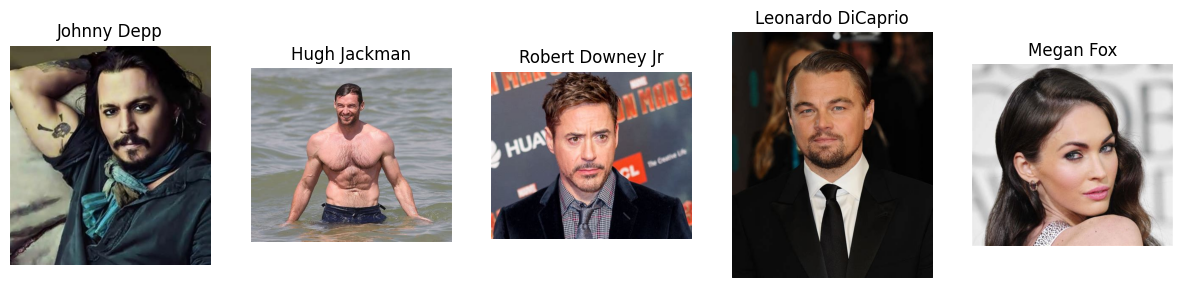

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import random
import os # Added import for os module

# Base path to "Celebrity Faces Dataset" folder
# Corrected base_path to use the 'path' variable from the dataset download cell
base_path = os.path.join(path, "Celebrity Faces Dataset")

# Get all class folders (celebrities)
classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
print(f"Found {len(classes)} classes:")
print(classes)

# Count images per class
print("\nNumber of images per class:")
for cls in classes:
    cls_path = os.path.join(base_path, cls)
    images = [f for f in os.listdir(cls_path) if f.endswith((".jpg", ".png"))]
    print(f"{cls}: {len(images)} images")

# Display a few random images per class
def show_random_images(base_path, classes, num_images=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        cls = random.choice(classes)
        cls_path = os.path.join(base_path, cls)
        img_file = random.choice(os.listdir(cls_path))
        img_path = os.path.join(cls_path, img_file)
        img = Image.open(img_path)
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    plt.show()

show_random_images(base_path, classes, num_images=5)

In [ ]:
import os

# Base path to "Celebrity Faces Dataset" folder
# Corrected base_path to use the 'path' variable from the dataset download cell
base_path = os.path.join(path, "Celebrity Faces Dataset")

# Get all class folders (celebrities)
classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

# Print number of classes and their names
print(f"Number of classes: {len(classes)}")
print("Classes:", classes)


Number of classes: 17
Classes: ['Angelina Jolie', 'Sandra Bullock', 'Nicole Kidman', 'Megan Fox', 'Johnny Depp', 'Natalie Portman', 'Tom Cruise', 'Brad Pitt', 'Jennifer Lawrence', 'Tom Hanks', 'Scarlett Johansson', 'Kate Winslet', 'Will Smith', 'Robert Downey Jr', 'Denzel Washington', 'Hugh Jackman', 'Leonardo DiCaprio']


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Base dataset path containing the 18 celebrity folders
base_path = os.path.join(path, "Celebrity Faces Dataset") # Corrected path

# Target path for organized dataset
output_path = "celebrity_dataset_split"

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Create directories for train/val/test
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_path, split), exist_ok=True)

# List only the 18 celebrity classes
classes = [d for d in os.listdir(base_path)
           if os.path.isdir(os.path.join(base_path, d))
           and not d.lower().startswith("0")
           and d.lower() != "celebrity faces dataset"]

print(f"Classes to split: {classes}")

# Split each class separately
for cls in classes:
    cls_path = os.path.join(base_path, cls)
    images = [f for f in os.listdir(cls_path) if f.endswith((".jpg", ".png"))]

    # Split into train and temp (val+test)
    train_files, temp_files = train_test_split(images, train_size=train_ratio, random_state=42)
    # Split temp into val and test
    val_files, test_files = train_test_split(temp_files, test_size=test_ratio/(test_ratio+val_ratio), random_state=42)

    # Copy files to respective directories
    for split_name, split_files in zip(["train", "val", "test"], [train_files, val_files, test_files]):
        split_cls_path = os.path.join(output_path, split_name, cls)
        os.makedirs(split_cls_path, exist_ok=True)
        for f in split_files:
            shutil.copy(os.path.join(cls_path, f), os.path.join(split_cls_path, f))

print("Dataset has been split into train, validation, and test sets.")

Classes to split: ['Angelina Jolie', 'Sandra Bullock', 'Nicole Kidman', 'Megan Fox', 'Johnny Depp', 'Natalie Portman', 'Tom Cruise', 'Brad Pitt', 'Jennifer Lawrence', 'Tom Hanks', 'Scarlett Johansson', 'Kate Winslet', 'Will Smith', 'Robert Downey Jr', 'Denzel Washington', 'Hugh Jackman', 'Leonardo DiCaprio']
Dataset has been split into train, validation, and test sets.


In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "celebrity_dataset_split/train",
    image_size=(128, 128),
    batch_size=32,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "celebrity_dataset_split/val",
    image_size=(128, 128),
    batch_size=32,
    label_mode="categorical"
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "celebrity_dataset_split/test",
    image_size=(128, 128),
    batch_size=32,
    label_mode="categorical"
)


Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Paths to your dataset splits
train_path = "celebrity_dataset_split/train"
val_path = "celebrity_dataset_split/val"
test_path = "celebrity_dataset_split/test"

# Image parameters
img_height = 128
img_width = 128
batch_size = 32
# Correct num_classes to 17, as inferred from the dataset loading output
num_classes = 17

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

# Normalize images
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Baseline CNN model
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=num_classes):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_baseline_cnn(num_classes=num_classes)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 0.0616 - loss: 2.9700 - val_accuracy: 0.1111 - val_loss: 2.8091
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1073 - loss: 2.7933 - val_accuracy: 0.1444 - val_loss: 2.6708
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1547 - loss: 2.6440 - val_accuracy: 0.2259 - val_loss: 2.4685
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2086 - loss: 2.4615 - val_accuracy: 0.2148 - val_loss: 2.3827
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2634 - loss: 2.2514 - val_accuracy: 0.2370 - val_loss: 2.2849
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3397 - loss: 2.0344 - val_accuracy: 0.2593 - val_loss: 2.2622
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4197 - loss: 1.7319 - val_accuracy: 0.2667 - val_loss: 2.2540
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4830 - loss: 1.5847 - val_accuracy: 0.2444 -

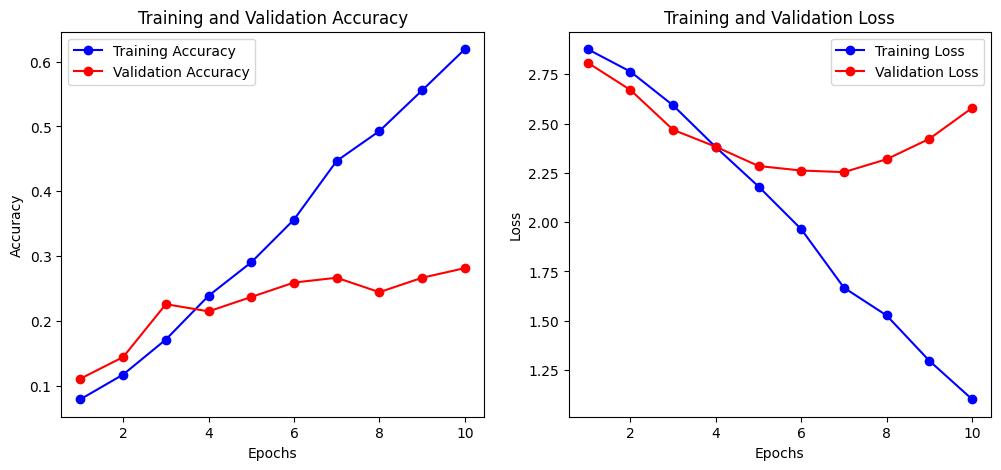

In [ ]:
import matplotlib.pyplot as plt

# Extract metrics from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc)+1)

# Plot Accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Found 270 files belonging to 17 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step


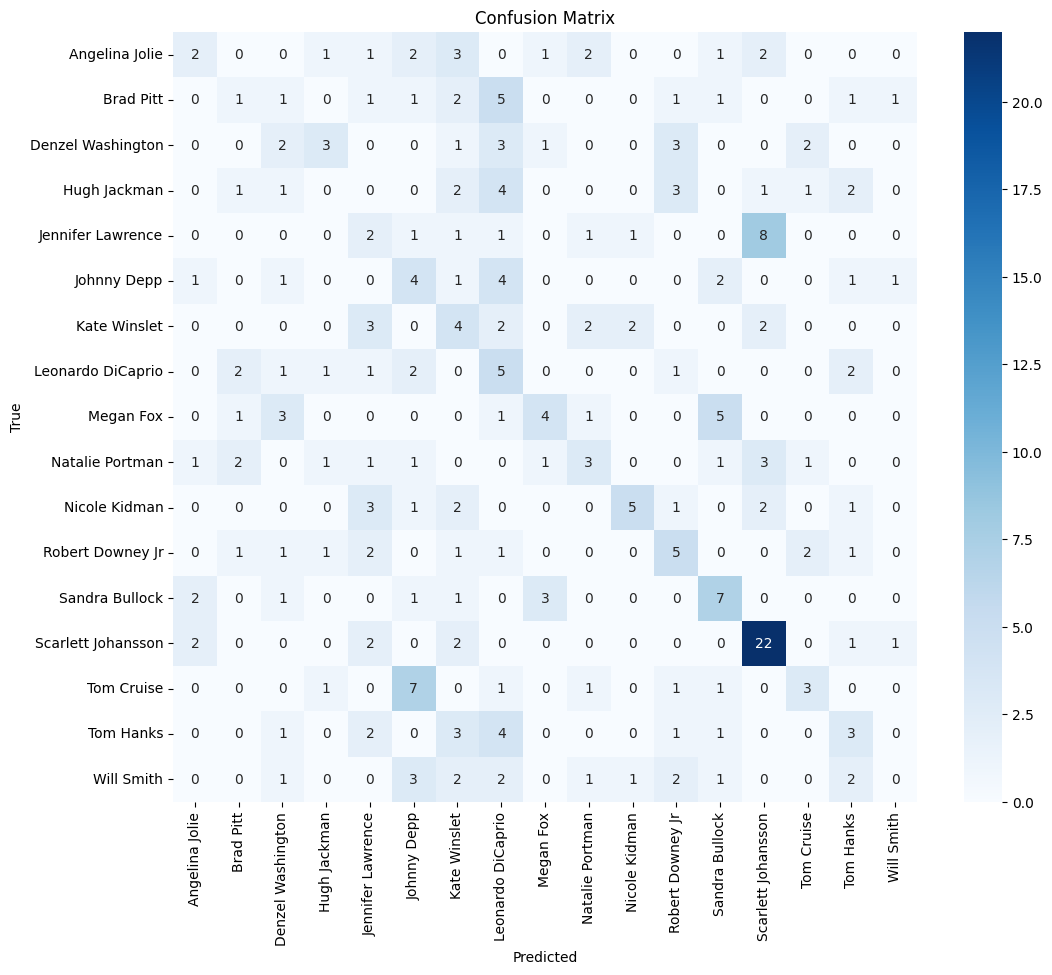

Classification Report:
                    precision    recall  f1-score   support

    Angelina Jolie       0.25      0.13      0.17        15
         Brad Pitt       0.12      0.07      0.09        15
 Denzel Washington       0.15      0.13      0.14        15
      Hugh Jackman       0.00      0.00      0.00        15
 Jennifer Lawrence       0.11      0.13      0.12        15
       Johnny Depp       0.17      0.27      0.21        15
      Kate Winslet       0.16      0.27      0.20        15
 Leonardo DiCaprio       0.15      0.33      0.21        15
         Megan Fox       0.40      0.27      0.32        15
   Natalie Portman       0.27      0.20      0.23        15
     Nicole Kidman       0.56      0.33      0.42        15
  Robert Downey Jr       0.28      0.33      0.30        15
    Sandra Bullock       0.35      0.47      0.40        15
Scarlett Johansson       0.55      0.73      0.63        30
        Tom Cruise       0.33      0.20      0.25        15
         Tom Han

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# Re-load test_ds to get class_names before normalization
# Or, even better, get it from train_ds or val_ds right after its creation if not already stored.
# Assuming train_ds was created by image_dataset_from_directory and retains class_names.
# We will get class names from the un-mapped train_ds created in the previous cell.
# If this is being run independently, one would recreate it here.
# For continuity, let's assume `train_ds` still holds the original dataset without map operation.
# However, the notebook state shows train_ds, val_ds, test_ds are already mapped.
# So, we need to explicitly get them before the mapping. Let's assume the unmapped versions exist
# or recreate them if necessary. Given the prior cell, they were created.

# To safely get class_names, we need to get it from a dataset created by image_dataset_from_directory
# *before* any .map() operations that turn it into a _MapDataset.
# The easiest way is to re-create a temporary dataset object for class_names.
temp_test_ds_for_names = tf.keras.preprocessing.image_dataset_from_directory(
    test_path, # test_path is defined in the previous cell
    image_size=(img_height, img_width), # img_height, img_width are defined in the previous cell
    batch_size=32,
    label_mode="categorical",
    shuffle=False # Shuffle not needed for just getting class names
)

class_names = temp_test_ds_for_names.class_names

# 1. Get true labels and predictions
y_true = []
y_pred = []

# Iterate over the *normalized* test_ds for actual predictions
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 4. Optional: classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Paths to your dataset splits
train_path = "celebrity_dataset_split/train"
val_path = "celebrity_dataset_split/val"
test_path = "celebrity_dataset_split/test"

# Image parameters
img_height = 128
img_width = 128
batch_size = 32
# Correct num_classes to 17, as inferred from the dataset loading output
num_classes = 17

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

# Normalize images
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Baseline CNN model
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=num_classes):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_baseline_cnn(num_classes=num_classes)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")


Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.0752 - loss: 3.0700 - val_accuracy: 0.1111 - val_loss: 2.8234
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1145 - loss: 2.8052 - val_accuracy: 0.1370 - val_loss: 2.7746
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1342 - loss: 2.7520 - val_accuracy: 0.1519 - val_loss: 2.7328
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1501 - loss: 2.6904 - val_accuracy: 0.1593 - val_loss: 2.6140
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1837 - loss: 2.5853 - val_accuracy: 0.1926 - val_loss: 2.5651
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2025 - loss: 2.4487 - val_accuracy: 0.2296 - val_loss: 2.3581
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2674 - loss: 2.2358 - val_accuracy: 0.2407 - val_loss: 2.3162
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2895 - loss: 2.1295 - val_accuracy: 0.2407 - val_l

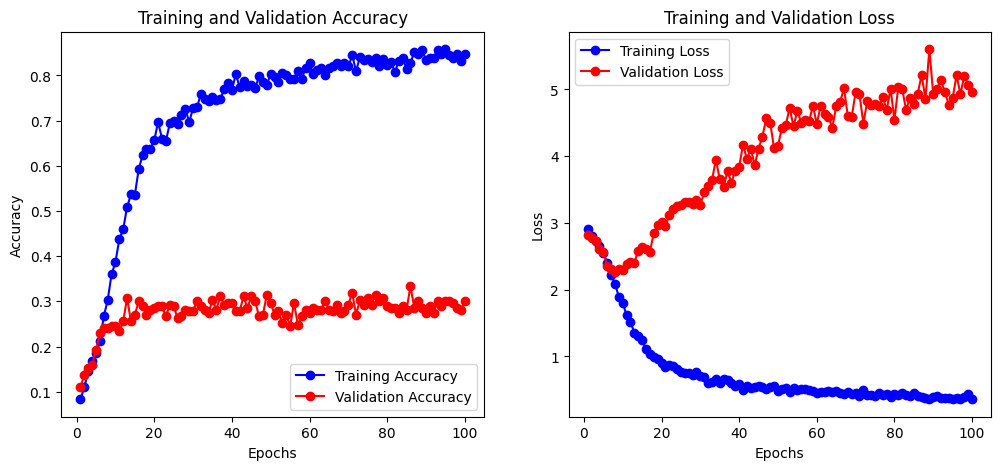

In [ ]:
# Extract metrics from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc)+1)

# Plot Accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Found 270 files belonging to 17 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step


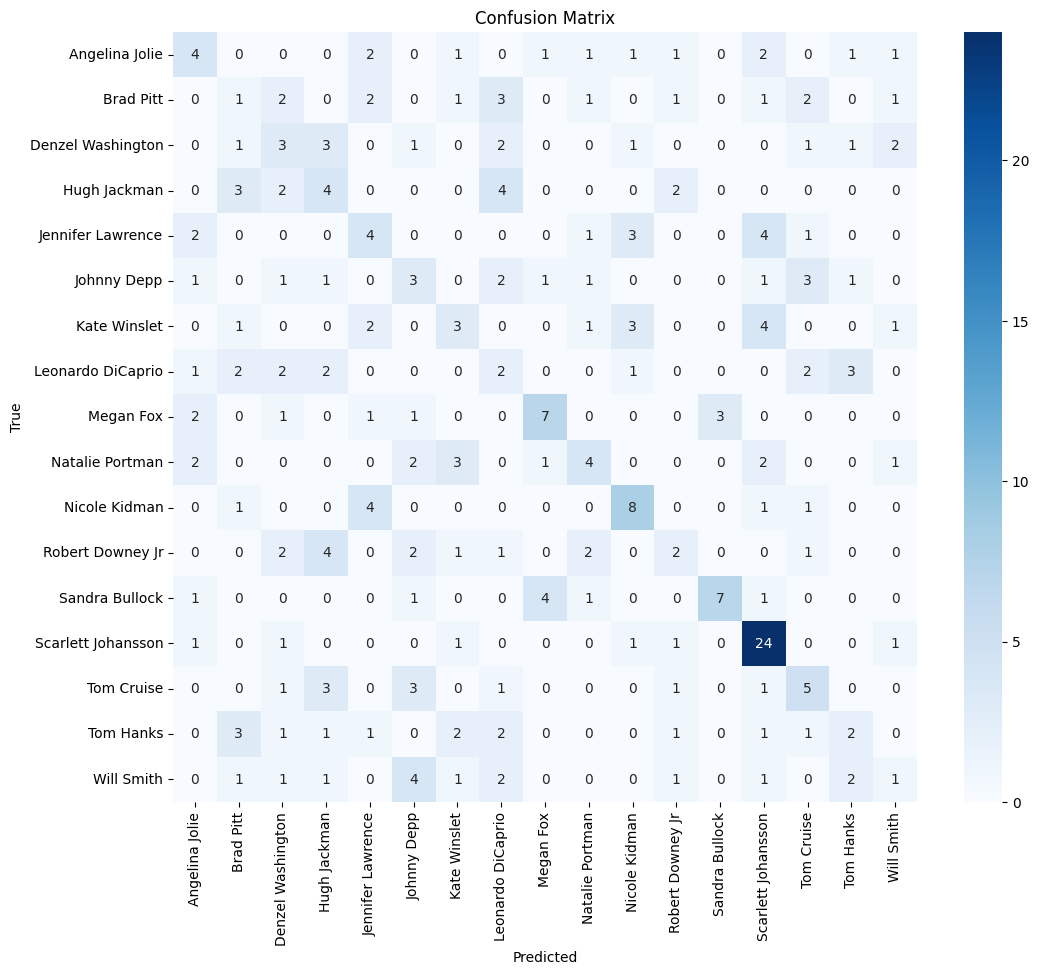

Classification Report:
                    precision    recall  f1-score   support

    Angelina Jolie       0.29      0.27      0.28        15
         Brad Pitt       0.08      0.07      0.07        15
 Denzel Washington       0.18      0.20      0.19        15
      Hugh Jackman       0.21      0.27      0.24        15
 Jennifer Lawrence       0.25      0.27      0.26        15
       Johnny Depp       0.18      0.20      0.19        15
      Kate Winslet       0.23      0.20      0.21        15
 Leonardo DiCaprio       0.11      0.13      0.12        15
         Megan Fox       0.50      0.47      0.48        15
   Natalie Portman       0.33      0.27      0.30        15
     Nicole Kidman       0.44      0.53      0.48        15
  Robert Downey Jr       0.20      0.13      0.16        15
    Sandra Bullock       0.70      0.47      0.56        15
Scarlett Johansson       0.56      0.80      0.66        30
        Tom Cruise       0.29      0.33      0.31        15
         Tom Han

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# Re-load test_ds to get class_names before normalization
# Or, even better, get it from train_ds or val_ds right after its creation if not already stored.
# Assuming train_ds was created by image_dataset_from_directory and retains class_names.
# We will get class names from the un-mapped train_ds created in the previous cell.
# If this is being run independently, one would recreate it here.
# For continuity, let's assume `train_ds` still holds the original dataset without map operation.
# However, the notebook state shows train_ds, val_ds, test_ds are already mapped.
# So, we need to explicitly get them before the mapping. Let's assume the unmapped versions exist
# or recreate them if necessary. Given the prior cell, they were created.

# To safely get class_names, we need to get it from a dataset created by image_dataset_from_directory
# *before* any .map() operations that turn it into a _MapDataset.
# The easiest way is to re-create a temporary dataset object for class_names.
temp_test_ds_for_names = tf.keras.preprocessing.image_dataset_from_directory(
    test_path, # test_path is defined in the previous cell
    image_size=(img_height, img_width), # img_height, img_width are defined in the previous cell
    batch_size=32,
    label_mode="categorical",
    shuffle=False # Shuffle not needed for just getting class names
)

class_names = temp_test_ds_for_names.class_names

# 1. Get true labels and predictions
y_true = []
y_pred = []

# Iterate over the *normalized* test_ds for actual predictions
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 4. Optional: classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.0826 - loss: 2.8392 - val_accuracy: 0.1111 - val_loss: 2.8149
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1219 - loss: 2.8026 - val_accuracy: 0.1333 - val_loss: 2.7455
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1398 - loss: 2.7253 - val_accuracy: 0.1556 - val_loss: 2.6424
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1421 - loss: 2.6387 - val_accuracy: 0.1704 - val_loss: 2.5907
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1767 - loss: 2.5629 - val_accuracy: 0.2111 - val_loss: 2.4304
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1877 - loss: 2.4958 - val_accuracy: 0.2111 - val_loss: 2.3061
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1874 - loss: 2.4511 - val_accuracy: 0.2185 - val_loss: 2.3219
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2051 - loss: 2.4331 - val_accuracy: 0.2444 - val_l

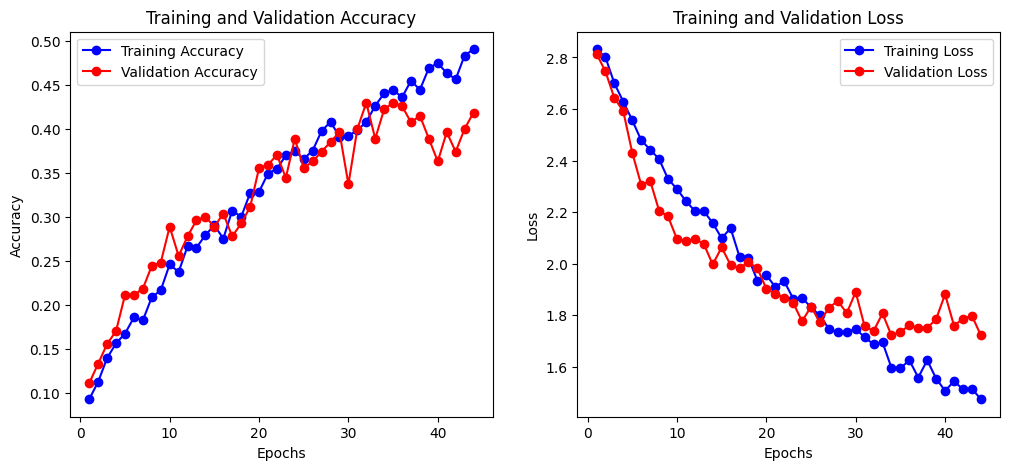

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Paths to your dataset splits
train_path = "celebrity_dataset_split/train"
val_path = "celebrity_dataset_split/val"
test_path = "celebrity_dataset_split/test"

# Image parameters
img_height = 128
img_width = 128
batch_size = 32
num_classes = 17  # As inferred from dataset loading

# Data augmentation pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

# Normalize images
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Baseline CNN with data augmentation and dropout
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=num_classes):
    model = models.Sequential([
        data_augmentation,  # Apply augmentation
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),  # Dropout for regularization
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_baseline_cnn(num_classes=num_classes)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Early stopping callback
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop]
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot training and validation loss & accuracy
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


# VGG16

Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.0738 - loss: 3.0577 - val_accuracy: 0.1037 - val_loss: 2.8348 - learning_rate: 1.0000e-04
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0772 - loss: 2.9175 - val_accuracy: 0.1111 - val_loss: 2.8073 - learning_rate: 1.0000e-04
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0912 - loss: 2.9017 - val_accuracy: 0.1111 - val_loss: 2.7940 - learning_rate: 1.0000e-04
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0756 - loss: 2.8811 - val_accuracy: 0.1148 - val_loss: 2.7811 - learning_rate: 1.0000e-04
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0963 - loss: 2.8573 - val_accuracy: 0.1185 - val_loss: 2.7690 - learning_rate: 1.0000e-04
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

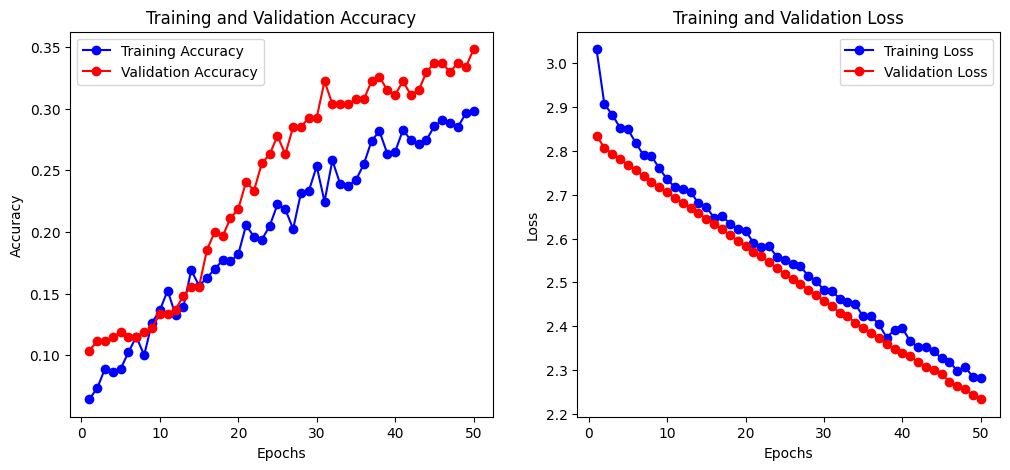

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# Paths to your dataset splits
train_path = "celebrity_dataset_split/train"
val_path = "celebrity_dataset_split/val"
test_path = "celebrity_dataset_split/test"

# Image parameters
img_height = 224  # VGG16 expects 224x224
img_width = 224
batch_size = 32
num_classes = 17  # as inferred from dataset

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Load datasets with batching
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

# Normalize images
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(tf.data.AUTOTUNE)

# Load VGG16 base model without top layers
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
vgg_base.trainable = False  # freeze base layers

# Build the model
inputs = layers.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
x = vgg_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

# Compile with Adam optimizer and learning rate reduction
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, lr_schedule]
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot accuracy and loss
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Found 270 files belonging to 17 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


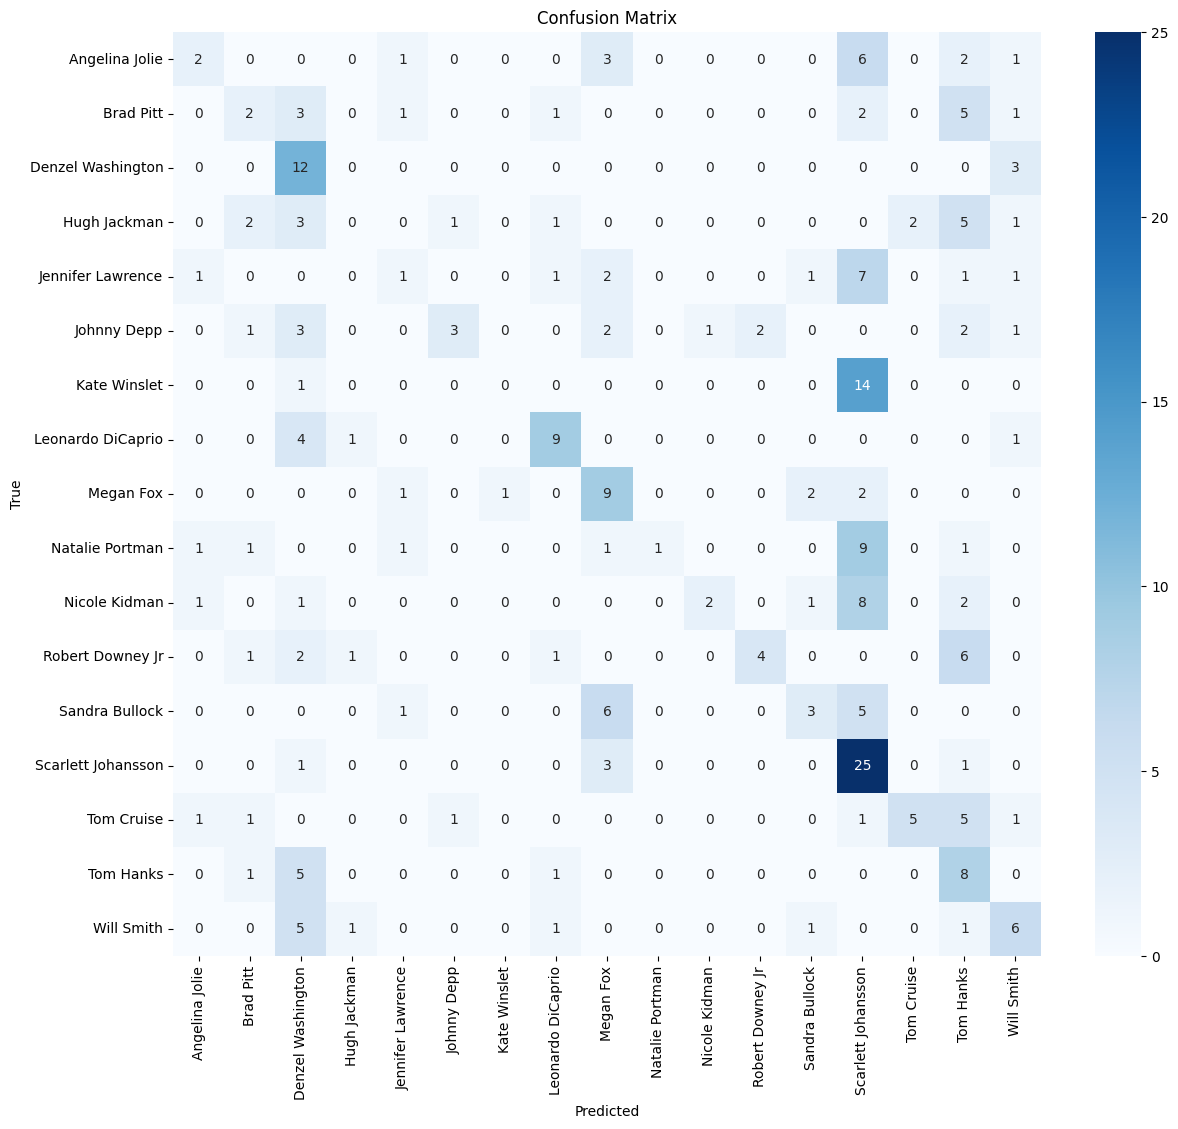

Classification Report:
                    precision    recall  f1-score   support

    Angelina Jolie       0.33      0.13      0.19        15
         Brad Pitt       0.22      0.13      0.17        15
 Denzel Washington       0.30      0.80      0.44        15
      Hugh Jackman       0.00      0.00      0.00        15
 Jennifer Lawrence       0.17      0.07      0.10        15
       Johnny Depp       0.60      0.20      0.30        15
      Kate Winslet       0.00      0.00      0.00        15
 Leonardo DiCaprio       0.60      0.60      0.60        15
         Megan Fox       0.35      0.60      0.44        15
   Natalie Portman       1.00      0.07      0.12        15
     Nicole Kidman       0.67      0.13      0.22        15
  Robert Downey Jr       0.67      0.27      0.38        15
    Sandra Bullock       0.38      0.20      0.26        15
Scarlett Johansson       0.32      0.83      0.46        30
        Tom Cruise       0.71      0.33      0.45        15
         Tom Han

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import tensorflow as tf

# To safely get class_names, we need to get it from a dataset created by image_dataset_from_directory
# *before* any .map() or .prefetch() operations.
temp_test_ds_for_names = tf.keras.preprocessing.image_dataset_from_directory(
    test_path, # test_path is defined in the previous cell
    image_size=(img_height, img_width), # img_height, img_width are defined in the previous cell
    batch_size=32,
    label_mode="categorical",
    shuffle=False # Shuffle not needed for just getting class names
)

class_names = temp_test_ds_for_names.class_names

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Optional: classification report with precision, recall, F1-score
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


# Fine tuning VGG16

Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.0734 - loss: 3.0851 - val_accuracy: 0.1111 - val_loss: 2.8572
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0830 - loss: 2.9507 - val_accuracy: 0.1111 - val_loss: 2.8108
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0668 - loss: 2.8996 - val_accuracy: 0.1111 - val_loss: 2.7874
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0855 - loss: 2.8672 - val_accuracy: 0.1111 - val_loss: 2.7735
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0903 - loss: 2.8747 - val_accuracy: 0.1111 - val_loss: 2.7601
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1259 - loss: 2.8065 - val_accuracy: 0.1111 - val_loss: 2.7461
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1112 - loss: 2.7951 - val_accuracy: 0.1148 - val_

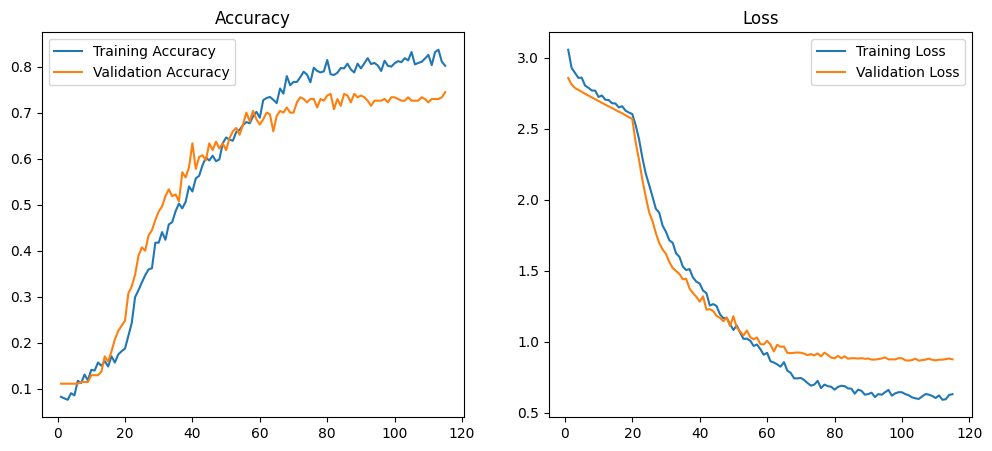

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Paths
train_path = "celebrity_dataset_split/train"
val_path = "celebrity_dataset_split/val"
test_path = "celebrity_dataset_split/test"

# Image parameters
img_height = 224
img_width = 224
batch_size = 32
num_classes = 17

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Load datasets
def load_dataset(path):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        label_mode="categorical",
        shuffle=True
    )
    ds = ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y))
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = load_dataset(train_path)
val_ds = load_dataset(val_path)
test_ds = load_dataset(test_path)

# VGG16 base
vgg_base = VGG16(weights='imagenet', include_top=False,
                 input_shape=(img_height, img_width, 3))
vgg_base.trainable = False  # freeze initially

# Build model
inputs = layers.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
x = vgg_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

# Compile top model
model.compile(optimizer=Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train classification head
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_top = model.fit(train_ds, validation_data=val_ds,
                        epochs=20, callbacks=[early_stop])

# Fine-tune VGG16 block 5
vgg_base.trainable = True
for layer in vgg_base.layers:
    layer.trainable = layer.name.startswith("block5")

# Recompile at lower LR
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

model.compile(optimizer=Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 🔥 Fine-tune for 100 epochs
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop, lr_schedule]
)

# ------------------------------
# Evaluate on Test Set
# ------------------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"Fine-tuned Test Accuracy: {test_acc:.4f}")

# ------------------------------
# Training History Plot
# ------------------------------
acc = history_top.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_top.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_top.history['loss'] + history_fine.history['loss']
val_loss = history_top.history['val_loss'] + history_fine.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend(); plt.title("Loss")
plt.show()

# ------------------------------
# Classification Report + Confusion Matrix
# ------------------------------
y_true = []
y_pred = []
class_names = test_ds.class_names

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()



Found 270 files belonging to 17 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step

CLASSIFICATION REPORT:

                    precision    recall  f1-score   support

    Angelina Jolie       0.73      0.53      0.62        15
         Brad Pitt       0.83      0.33      0.48        15
 Denzel Washington       0.54      0.87      0.67        15
      Hugh Jackman       0.60      0.60      0.60        15
 Jennifer Lawrence       0.75      0.60      0.67        15
       Johnny Depp       0.87      0.87      0.87        15
      Kate Winslet       0.79      0.73      0.76        15
 Leonardo DiCaprio       0.72      0.87      0.79        15
         Megan Fox       0.86      0.80      0.83

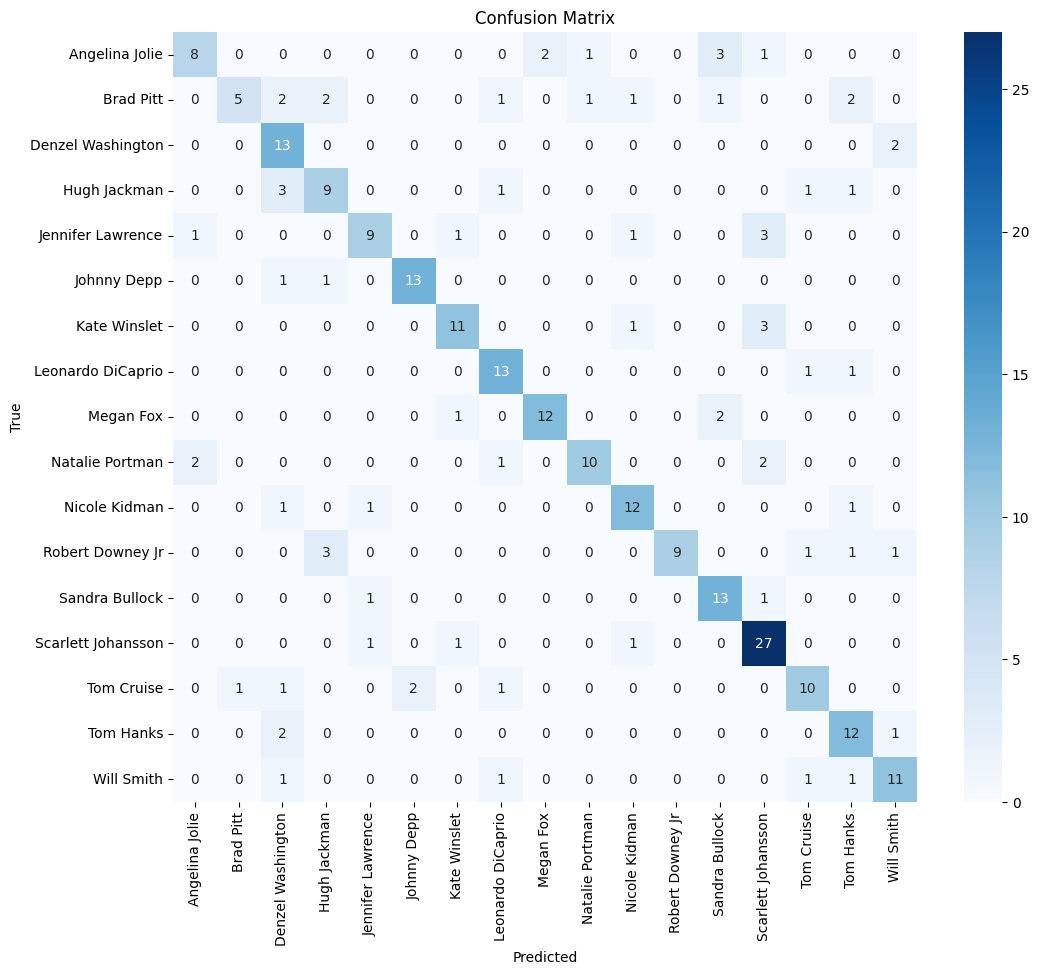

In [ ]:
# Extract class names before mapping/prefetching
raw_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(img_height, img_width),
    batch_size=batch_size
)
class_names = raw_test_ds.class_names

# Now run classification evaluation
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.0673 - loss: 3.0950 - val_accuracy: 0.1111 - val_loss: 2.8469
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0764 - loss: 2.9602 - val_accuracy: 0.1111 - val_loss: 2.8079
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0834 - loss: 2.9010 - val_accuracy: 0.1111 - val_loss: 2.7923
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0834 - loss: 2.8732 - val_accuracy: 0.1111 - val_loss: 2.7794
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0853 - loss: 2.8676 - val_accuracy: 0.1111 - val_loss: 2.7699
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1136 - loss: 2.8075 - val_accuracy: 0.1148 - val_loss: 2.7605
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0902 - loss: 2.8227 - val_accuracy: 0.1148 - val_

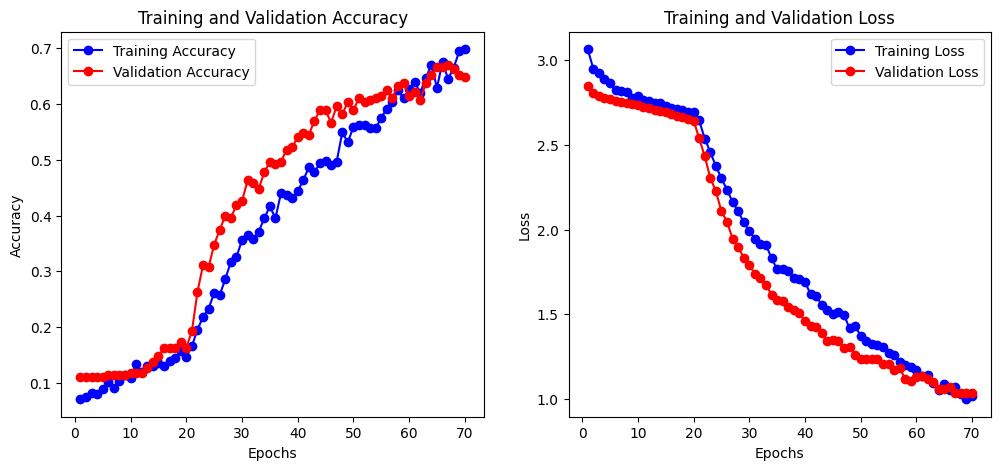

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# Paths
train_path = "celebrity_dataset_split/train"
val_path = "celebrity_dataset_split/val"
test_path = "celebrity_dataset_split/test"

# Image parameters
img_height = 224
img_width = 224
batch_size = 32
num_classes = 17

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Load datasets
def load_dataset(path):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        label_mode="categorical",
        shuffle=True
    )
    ds = ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y))
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = load_dataset(train_path)
val_ds = load_dataset(val_path)
test_ds = load_dataset(test_path)

# VGG16 base
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
vgg_base.trainable = False  # freeze initially

# Build the model
inputs = layers.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
x = vgg_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

# Compile top model
model.compile(optimizer=Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train top classifier first
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_top = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[early_stop])

# --- Fine-tuning: unfreeze last VGG16 block ---
vgg_base.trainable = True
for layer in vgg_base.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

# Compile with lower LR for fine-tuning
lr_schedule = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
model.compile(optimizer=Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune
history_fine = model.fit(train_ds,
                         validation_data=val_ds,
                         epochs=50,
                         callbacks=[early_stop, lr_schedule])

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"Fine-tuned Test Accuracy: {test_acc:.4f}")

# Plot combined training history
import matplotlib.pyplot as plt

acc = history_top.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_top.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_top.history['loss'] + history_fine.history['loss']
val_loss = history_top.history['val_loss'] + history_fine.history['val_loss']
epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# Paths
train_path = "celebrity_dataset_split/train"
val_path = "celebrity_dataset_split/val"
test_path = "celebrity_dataset_split/test"

# Image parameters
img_height = 224
img_width = 224
batch_size = 32
num_classes = 17

# Stronger data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

# Load datasets
def load_dataset(path):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        label_mode="categorical",
        shuffle=True
    )
    ds = ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y))
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = load_dataset(train_path)
val_ds = load_dataset(val_path)
test_ds = load_dataset(test_path)

# Load VGG16
vgg_base = VGG16(include_top=False, weights="imagenet",
                 input_shape=(img_height, img_width, 3))

# Freeze all layers initially
vgg_base.trainable = False

# Build top classifier
inputs = layers.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
x = vgg_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(
    256,
    activation='relu',
    kernel_regularizer=regularizers.l2(1e-4)   # L2 regularization
)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

# Compile classifier
model.compile(
    optimizer=Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

# Early Stop
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train top classifier first
history_top = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

# ----------------------------------------------------------
# ⭐ FINE-TUNING: unfreeze block4 + block5 of VGG16
# ----------------------------------------------------------
for layer in vgg_base.layers:
    if layer.name.startswith("block4") or layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

# Low LR for fine-tuning
model.compile(
    optimizer=Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

# Cosine Learning Rate (optional but recommended)
cosine_lr = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-5,
    first_decay_steps=200
)

model.optimizer.learning_rate = cosine_lr

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop]
)

test_loss, test_acc = model.evaluate(test_ds)
print(f"Improved Fine-Tuned Test Accuracy: {test_acc:.4f}")


Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.0516 - loss: 3.1300 - val_accuracy: 0.0704 - val_loss: 2.8976
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0465 - loss: 2.9969 - val_accuracy: 0.1111 - val_loss: 2.8665
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0753 - loss: 2.9525 - val_accuracy: 0.1111 - val_loss: 2.8581
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0725 - loss: 2.9555 - val_accuracy: 0.1111 - val_loss: 2.8514
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0748 - loss: 2.9295 - val_accuracy: 0.1111 - val_loss: 2.8466
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0729 - loss: 2.9189 - val_accuracy: 0.1111 - val_loss: 2.8433
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0694 - loss: 2.9322 - val_accuracy: 0.1111 - val_

Found 270 files belonging to 17 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


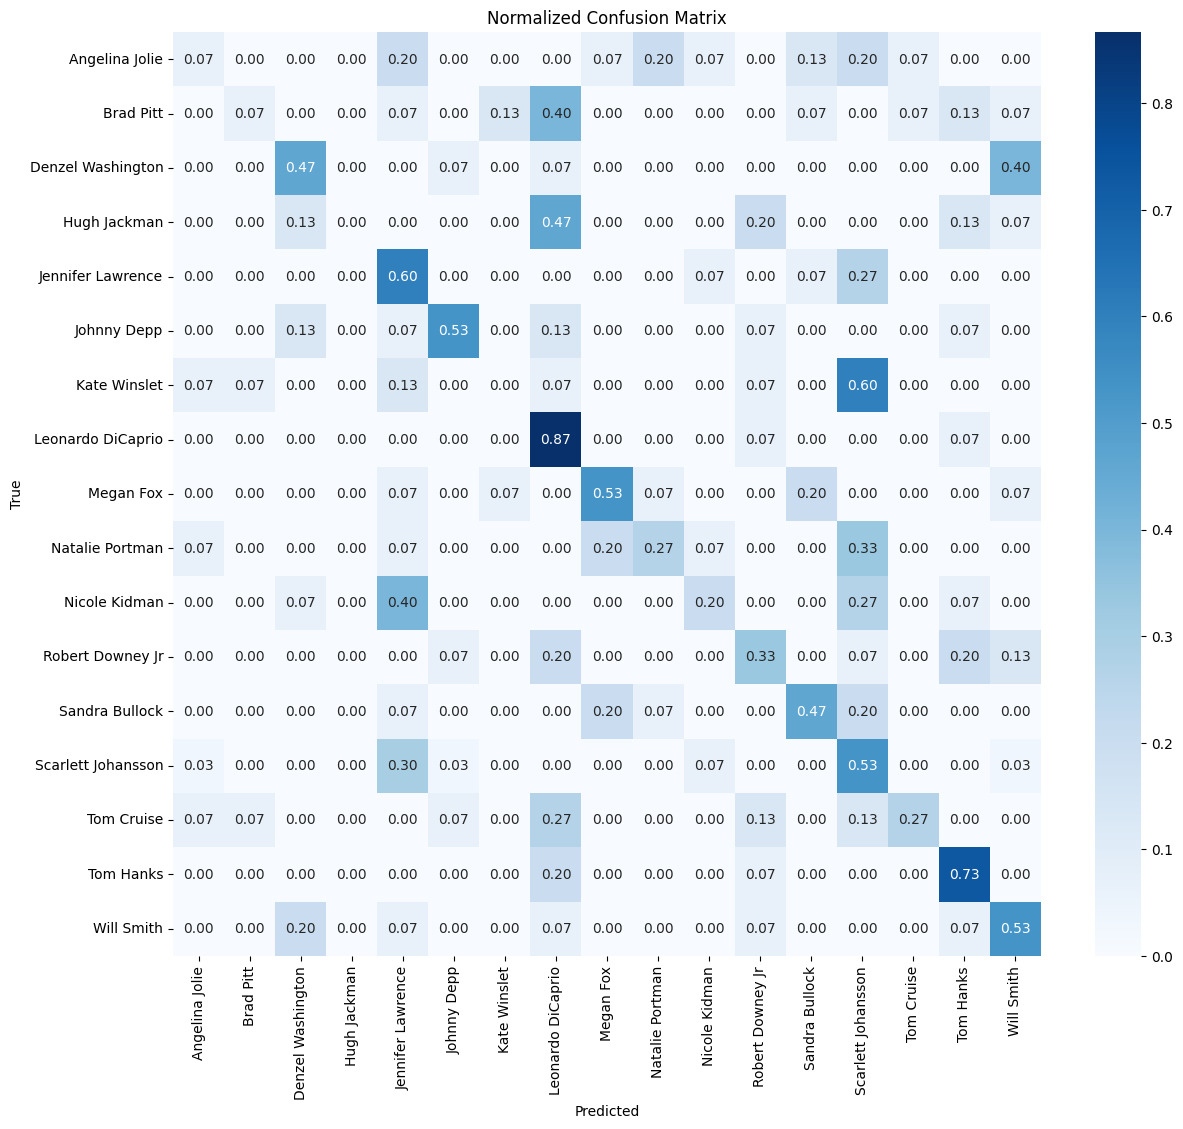

Classification Report:

                    precision    recall  f1-score   support

    Angelina Jolie       0.20      0.07      0.10        15
         Brad Pitt       0.33      0.07      0.11        15
 Denzel Washington       0.47      0.47      0.47        15
      Hugh Jackman       0.00      0.00      0.00        15
 Jennifer Lawrence       0.26      0.60      0.36        15
       Johnny Depp       0.67      0.53      0.59        15
      Kate Winslet       0.00      0.00      0.00        15
 Leonardo DiCaprio       0.32      0.87      0.46        15
         Megan Fox       0.53      0.53      0.53        15
   Natalie Portman       0.44      0.27      0.33        15
     Nicole Kidman       0.38      0.20      0.26        15
  Robert Downey Jr       0.33      0.33      0.33        15
    Sandra Bullock       0.50      0.47      0.48        15
Scarlett Johansson       0.34      0.53      0.42        30
        Tom Cruise       0.67      0.27      0.38        15
         Tom Ha

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf # Import tensorflow if not already present

# To safely get class_names, we need to get it from a dataset created by image_dataset_from_directory
# *before* any .map() or .prefetch() operations.
temp_test_ds_for_names = tf.keras.preprocessing.image_dataset_from_directory(
    test_path, # test_path is defined in the previous cell
    image_size=(img_height, img_width), # img_height, img_width are defined in the previous cell
    batch_size=32,
    label_mode="categorical",
    shuffle=False # Shuffle not needed for just getting class names
)

class_names = temp_test_ds_for_names.class_names  # List of class names

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14,12))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)


## EfficientNet

Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.0857 - loss: 2.8640 - val_accuracy: 0.1111 - val_loss: 2.8158 - learning_rate: 1.0000e-04
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1157 - loss: 2.8185 - val_accuracy: 0.1111 - val_loss: 2.8154 - learning_rate: 1.0000e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.0909 - loss: 2.8445 - val_accuracy: 0.1111 - val_loss: 2.8158 - learning_rate: 1.0000e-04
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.1195 - loss: 2.8252 - val_accuracy: 0.1111 - val_loss: 2.8146 - learning_rate: 1.0000e-04
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1153 - loss: 2.8159 - val_accuracy: 0.1111 - val_loss: 2.8153 - learning_rate: 1.0000e-04
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/st

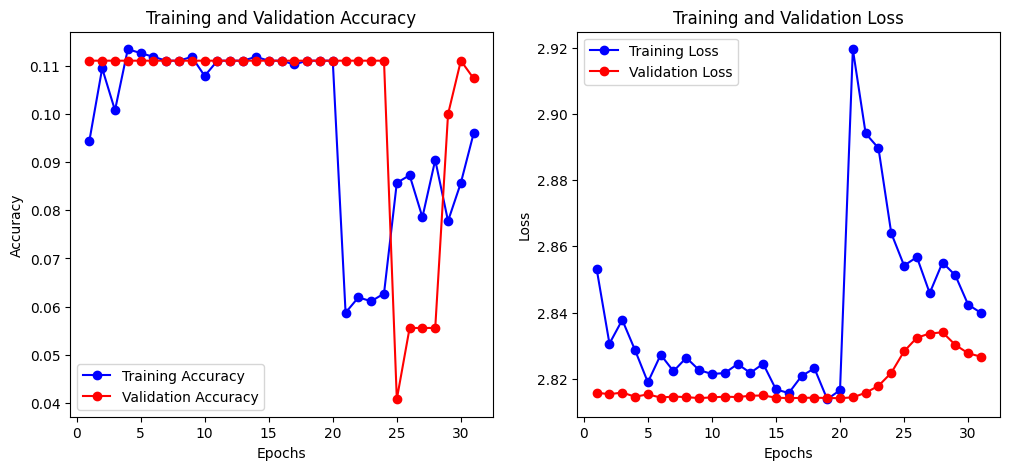

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Paths
train_path = "celebrity_dataset_split/train"
val_path = "celebrity_dataset_split/val"
test_path = "celebrity_dataset_split/test"

# Image parameters
img_height = 224
img_width = 224
batch_size = 32
num_classes = 17

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# Load datasets with batching and normalization
def load_dataset(path):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        label_mode="categorical",
        shuffle=True
    )
    ds = ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y))
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = load_dataset(train_path)
val_ds = load_dataset(val_path)
test_ds = load_dataset(test_path)

# Load EfficientNetB0 base model without top layers
efficient_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
efficient_base.trainable = False  # freeze base initially

# Build the model
inputs = layers.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
x = efficient_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

# Compile
lr_schedule = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.compile(optimizer=Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Stage 1: Train top classifier
history_top = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, lr_schedule]
)

# Stage 2: Fine-tune last EfficientNet blocks
efficient_base.trainable = True
for layer in efficient_base.layers[:-50]:  # freeze all but last 50 layers
    layer.trainable = False

model.compile(optimizer=Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, lr_schedule]
)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot combined training history
acc = history_top.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_top.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_top.history['loss'] + history_fine.history['loss']
val_loss = history_top.history['val_loss'] + history_fine.history['val_loss']
epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


## ResNet50

Found 1260 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
Found 270 files belonging to 17 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - accuracy: 0.0497 - loss: 3.4156 - val_accuracy: 0.1111 - val_loss: 2.8280 - learning_rate: 1.0000e-04
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.0660 - loss: 3.0155 - val_accuracy: 0.1111 - val_loss: 2.8142 - learning_rate: 1.0000e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.0754 - loss: 2.9112 - val_accuracy: 0.1111 - val_loss: 2.8103 - learning_rate: 1.0000e-04
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.0849 - loss: 2.8709 - val_accuracy: 0.1111 - val_loss: 2.8072 - learning_rate: 1.0000e-04
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.0997 - loss: 2.8469 - val_accuracy: 0.1111 - val_loss: 2.8042 - learning_rate: 1.0000e-04
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/st

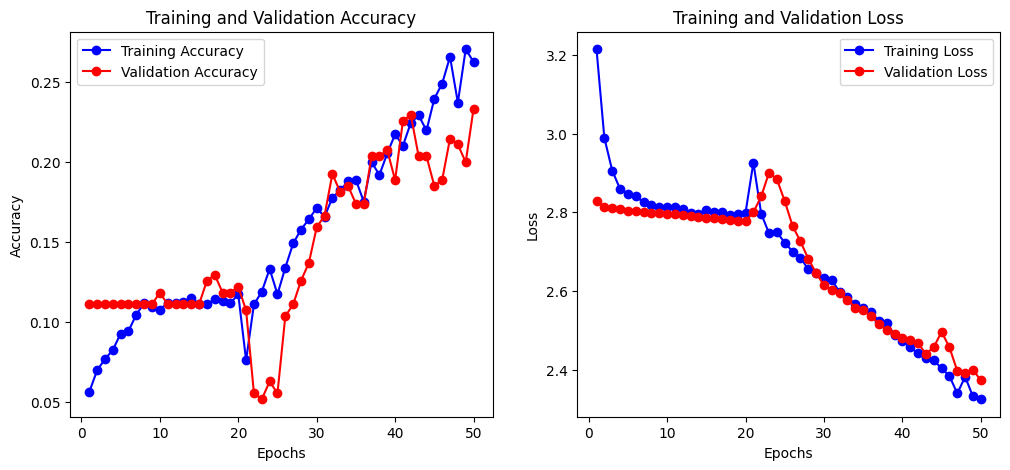

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Paths
train_path = "celebrity_dataset_split/train"
val_path = "celebrity_dataset_split/val"
test_path = "celebrity_dataset_split/test"

# Image parameters
img_height = 224
img_width = 224
batch_size = 32
num_classes = 17  # your dataset classes

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# Load datasets
def load_dataset(path):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        label_mode='categorical',
        shuffle=True
    )
    ds = ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y))
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = load_dataset(train_path)
val_ds = load_dataset(val_path)
test_ds = load_dataset(test_path)

# Load ResNet50 base
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
resnet_base.trainable = False  # Freeze base initially

# Build the model
inputs = layers.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
x = resnet_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

# Compile
lr_schedule = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Train top classifier
history_top = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, lr_schedule]
)

# Fine-tuning: unfreeze last 1-2 ResNet blocks
resnet_base.trainable = True
for layer in resnet_base.layers[:-50]:  # freeze all except last 50 layers
    layer.trainable = False

model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, lr_schedule]
)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot combined training history
acc = history_top.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_top.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_top.history['loss'] + history_fine.history['loss']
val_loss = history_top.history['val_loss'] + history_fine.history['val_loss']
epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


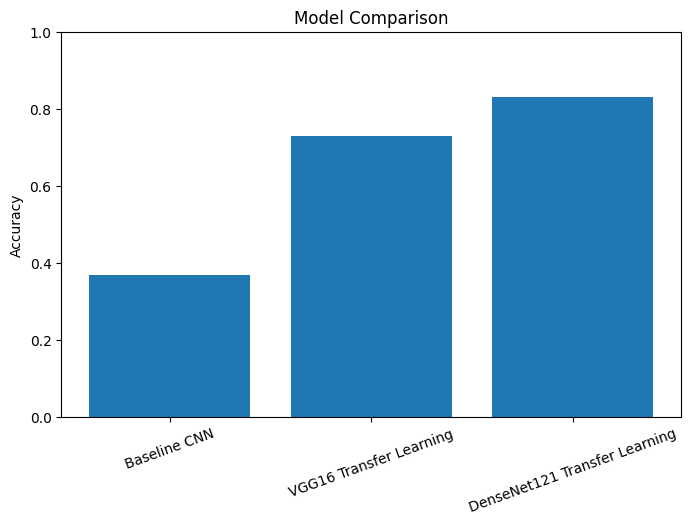

In [ ]:
import matplotlib.pyplot as plt

models = ["Baseline CNN", "VGG16 Transfer Learning", "DenseNet121 Transfer Learning"]
accuracy = [0.37, 0.73, 0.83]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()
